# Chaotic systems

Chaotic systems are *deterministic* yet unpredictable: fully specified equations whose sensitivity to initial conditions produces series that look random but have rich hidden structure. They test whether a model captures nonlinear dynamics rather than just fitting noise.

::: {.callout-note}
## The model

$$x_{n+1} = r\, x_n (1 - x_n) \quad \text{(logistic map; \texttt{lorenz} and \texttt{mackey\_glass} differ)}$$

Choose a classic system via `system` — `lorenz` (a strange attractor), `logistic` (the period-doubling map), or `mackey_glass` (a delay-differential equation). Each is generated by iterating its exact dynamics, so the same seed and parameters reproduce the trajectory precisely.
:::

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import ChaoticSystemGenerator

## 1. The three systems

Each system is fully deterministic given its initial condition, yet none looks periodic. `lorenz` is a continuous attractor sampled once per time unit, `logistic` is a period-doubling map, and `mackey_glass` is a delay-differential equation.


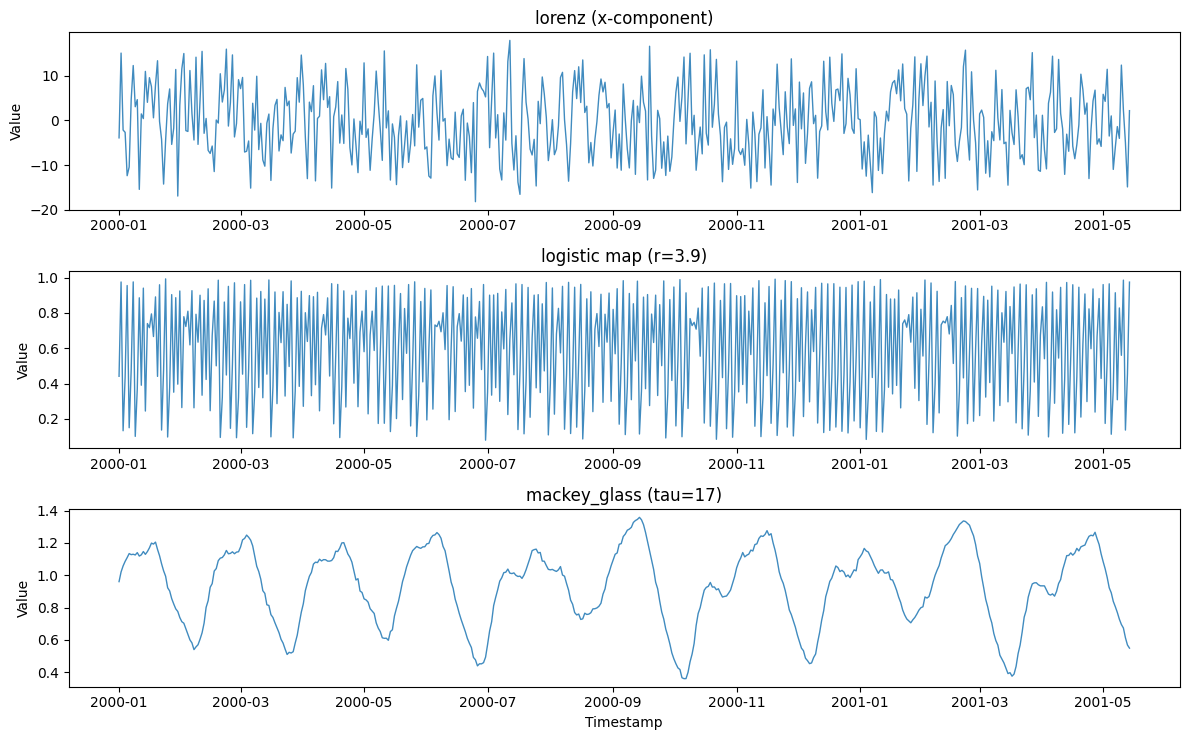

In [ ]:
lorenz_df = ChaoticSystemGenerator(
    engine="polars",
    min_length=500,
    max_length=500,
    freq="D",
    system="lorenz",
    observation_noise=0.1,
    seed=42,
).generate(n_series=1)

logistic_df = ChaoticSystemGenerator(
    engine="polars",
    min_length=500,
    max_length=500,
    freq="D",
    system="logistic",
    logistic_r=3.9,
    observation_noise=0.01,
    seed=42,
).generate(n_series=1)

mackey_glass_df = ChaoticSystemGenerator(
    engine="polars",
    min_length=500,
    max_length=500,
    freq="D",
    system="mackey_glass",
    mg_tau=17,
    observation_noise=0.01,
    seed=42,
).generate(n_series=1)

panels = [
    ("lorenz (x-component)", lorenz_df),
    ("logistic map (r=3.9)", logistic_df),
    ("mackey_glass (tau=17)", mackey_glass_df),
]
fig, axes = plt.subplots(3, 1, figsize=(12, 7.5), sharex=False)
for ax, (label, df) in zip(axes, panels):
    ax.plot(df["ds"].to_list(), df["y"].to_list(), alpha=0.85, linewidth=1)
    ax.set(ylabel="Value", title=label)
axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()


## 2. Sensitivity to initial conditions

Multiple series from the same chaotic system diverge due to tiny differences in initial perturbations.

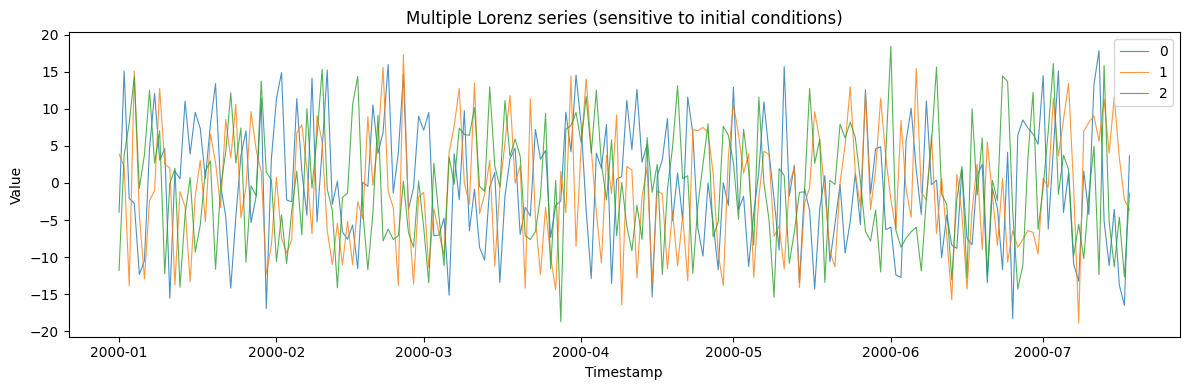

In [ ]:
multi_gen = ChaoticSystemGenerator(engine="polars", 
    min_length=200, max_length=200, freq="D",
    system="lorenz", seed=42,
)
multi_df = multi_gen.generate(n_series=3)

fig, ax = plt.subplots(figsize=(12, 4))
for uid in multi_df["unique_id"].unique().to_list():
    series = multi_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8, linewidth=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Multiple Lorenz series (sensitive to initial conditions)")
ax.legend()
plt.tight_layout()
plt.show()

::: {.callout-tip}
## Related generators

- [Cyclic](/synforecast/docs/generators/stochastic/cyclic.html) — irregular but stochastic oscillation.
- [State space](/synforecast/docs/generators/domain/state_space.html) — custom deterministic-plus-noise dynamics.

Available systems and parameters are in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::